# Homework 4 — U-Net Training

`smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet')` with
**BCE + Dice** loss. 30 epochs, save best by validation Dice.

In [1]:
import os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}   smp: {smp.__version__}")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

Device: cuda   smp: 0.5.0


## 1. Dataset + augmentations

In [2]:
ROOT = "datasets/bbbc010_seg"
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    # TODO (Ex 2): geometric augmentations, all with p=0.5
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

class WormDataset(Dataset):
    def __init__(self, split, transform):
        self.img_dir  = os.path.join(ROOT, split, "images")
        self.mask_dir = os.path.join(ROOT, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        f = self.files[i]
        img  = np.array(Image.open(os.path.join(self.img_dir,  f)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, f)).convert("L")) // 255
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0).float()

train_ds = WormDataset("train", train_tf)
val_ds   = WormDataset("test",  eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}")

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

train=80  val=20


## 2. Model + loss

In [3]:
# TODO (Ex 2): EfficientNet-B0 backbone, ImageNet weights, 3-channel input, 1-class output
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

bce  = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary")
# TODO (Ex 2): combined loss = equal-weight mix of BCE and Dice
def loss_fn(logits, y): return 0.5 * bce(logits, y) + 0.5 * dice(logits, y)

@torch.no_grad()
def dice_iou(logits, y, thr=0.5):
    # TODO (Ex 2): apply sigmoid, then threshold at thr
    pred = (torch.sigmoid(logits) > thr).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred, y.long(), mode="binary")
    return (smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro").item(),
            smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item())

Params: 6.25 M


## 3. Training loop (30 epochs, save best by val Dice)

In [4]:
# TODO (Ex 2): 30 epochs; Adam LR 1e-4 for fine-tuning a pretrained encoder
EPOCHS = 30
LR = 1e-4
CKPT = "checkpoints/unet_efficientnet-b0.pt"
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward(); opt.step()
        tr_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    sched.step()

    model.eval()
    vl, vd, vi = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vl.append(loss_fn(logits, y).item())
            d, i = dice_iou(logits, y); vd.append(d); vi.append(i)
    tr_mean = float(np.mean(tr_losses)); vl_mean = float(np.mean(vl))
    vd_mean = float(np.mean(vd));        vi_mean = float(np.mean(vi))
    history["train_loss"].append(tr_mean); history["val_loss"].append(vl_mean)
    history["val_dice"].append(vd_mean);   history["val_iou"].append(vi_mean)
    flag = ""
    if vd_mean > best:
        best = vd_mean
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_dice": vd_mean}, CKPT)
        flag = "  ★ new best"
    print(f"epoch {epoch:02d}  train={tr_mean:.3f}  val={vl_mean:.3f}  "
          f"dice={vd_mean:.3f}  iou={vi_mean:.3f}{flag}")

print(f"\nBest val Dice = {best:.4f}  →  {CKPT}")

epoch 01  train=0.859  val=0.887  dice=0.100  iou=0.052  ★ new best


epoch 02  train=0.738  val=0.783  dice=0.109  iou=0.058  ★ new best


epoch 03  train=0.662  val=0.723  dice=0.115  iou=0.061  ★ new best


epoch 04  train=0.606  val=0.674  dice=0.494  iou=0.328  ★ new best


epoch 05  train=0.568  val=0.652  dice=0.612  iou=0.442  ★ new best


...

epoch 26  train=0.355  val=0.425  dice=0.828  iou=0.708


epoch 27  train=0.354  val=0.411  dice=0.832  iou=0.713


epoch 28  train=0.353  val=0.395  dice=0.840  iou=0.725  ★ new best


epoch 29  train=0.353  val=0.385  dice=0.849  iou=0.738  ★ new best


epoch 30  train=0.353  val=0.377  dice=0.856  iou=0.749  ★ new best

Best val Dice = 0.8563  →  checkpoints/unet_efficientnet-b0.pt


## 4. Training curves

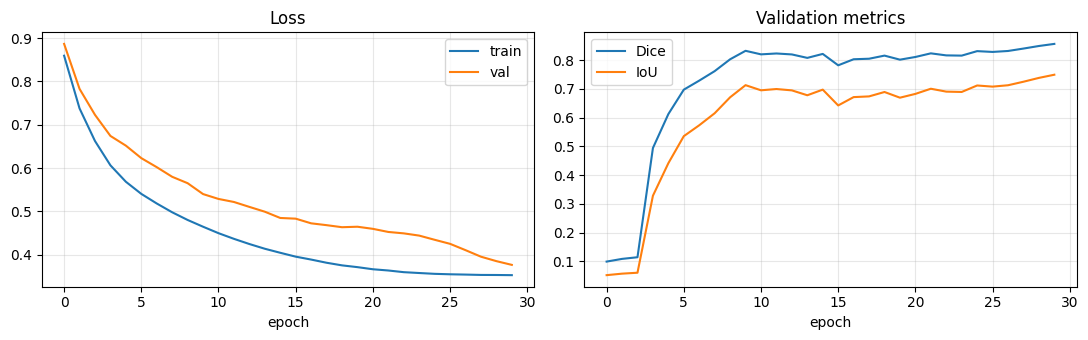

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history["val_dice"], label="Dice"); ax[1].plot(history["val_iou"], label="IoU")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusion

Best checkpoint saved. Move on to `02_Evaluation.ipynb`.